# Taller ingeniería de datos CRISTIAN CAMILO HERNANDEZ

El problema que se desea resolver haciendo un modelo predictivo es el siguiente:

*En la industria de telecomunicaciones, la **retención de clientes** es uno de los mayores desafíos para las empresas, ya que la pérdida de clientes (churn) afecta directamente los ingresos y la sostenibilidad del negocio. En este contexto, la empresa que proporciona servicios de telecomunicaciones a través del dataset tiene como objetivo reducir la **tasa de cancelación de sus servicios**. En particular, la variable **Churn Label** identifica a aquellos clientes que han decidido abandonar el servicio. Para abordar este problema, es crucial predecir con antelación qué clientes podrían cancelar su suscripción, para implementar estrategias de retención específicas. Este análisis predictivo no solo ayudaría a identificar a los clientes en riesgo de churn, sino que también podría revelar factores determinantes como la **razón de cancelación**, **tipos de contrato**, **método de pago**, **tasa de uso** y otras variables que influyen en la decisión de los clientes. Por lo tanto, realizar un análisis predictivo basado en estas variables permitirá a la empresa tomar medidas proactivas para mejorar su **estrategia de fidelización** y, en última instancia, reducir el churn y aumentar la **rentabilidad** a largo plazo.*

El equipo de análisis cuenta con un dataset cuyo diccionario de datos se puede consultar en [IBM](https://community.ibm.com/community/user/businessanalytics/blogs/steven-macko/2019/07/11/telco-customer-churn-1113).

## Carga e identificación de problemas de los datos

Abra el archivo de datos en Excel o bloc de notas, y revise sí hay algo particular con los datos. Este paso es importante para evitar problemas posteriores al cargar los datos.

Cargue en `Pandas` el archivo dado, que contiene un dataset cuya información puede consultar en [IBM](https://community.ibm.com/community/user/businessanalytics/blogs/steven-macko/2019/07/11/telco-customer-churn-1113).

Indique cuántas variables y registros tiene el dataset, y asegúrese que el tipo de dato de cada variable sea el esperado.

Reporte las estadísticas descriptivas de las variables numéricas y categóricas.

Identifique si el dataframe tiene datos duplicados.

Identifique si hay variables con datos nulos.

Reporte los hallazgos en un celda de texto.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Cargando el archivo en pandas

dataset = pd.read_csv(r"../data/Telco_customer_churn.csv")

dataset.head(3)

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved


In [2]:
# Indique cuántas variables y registros tiene el dataset, y asegúrese que el tipo de dato de cada variable sea el esperado.
print(20*"*")

#Numero de variables
print(f"Existen un total de {dataset.shape[1]} variables ")
print(dataset.columns)

print(20*"*")
#Registros del dataset
print(dataset.size)

print(20*"*")

print("Aseguramiento tipo de dato")
registros, variables = dataset.shape
print(f"Registros: {registros}")
print(f"Variables: {variables}")

dataset.info()

********************
Existen un total de 33 variables 
Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
       'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='object')
********************
232419
********************
Aseguramiento tipo de dato
Registros: 7043
Variables: 33
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count         

Descarte las variables que considere irrelevantes para su modelo (p.e. claves priamrias, variables con valores únicos, variables redundantes, entre otros).

Gestione los datos duplicados y los datos nulos.

In [3]:
# Variables descartables por tener informacion no relevante o tener data leakage
variables_disposable = ["CustomerID", "Count", "Lat Long", "Country", "Churn Label", "CLTV"]

# Eliminar columnas irrelevantes / leakage
dataset.drop(columns=variables_disposable, inplace=True)

# Eliminar duplicados exactos
dataset.drop_duplicates(inplace=True)

# Imputación simple para no perder clases por dropna global
cat_cols = dataset.select_dtypes(include=["object"]).columns
num_cols = dataset.select_dtypes(exclude=["object"]).columns

# Categóricas: moda
dataset[cat_cols] = dataset[cat_cols].fillna(dataset[cat_cols].mode().iloc[0])
# Numéricas: mediana
dataset[num_cols] = dataset[num_cols].fillna(dataset[num_cols].median())


## Análisis de variables categóricas

Haga un análisis de las variables categóricas no descartadas, e identifique:

- Variables nominales.
- Variables ordinales.
- Variables con alta cardinalidad.
- Variables que no deberían incluirse en la matriz de características.

Reporte los resultados del análisis en una celda de texto.

In [4]:
# Análisis de variables categóricas
cat_cols = dataset.select_dtypes(include=["object"]).columns.tolist()

# Ordinales 
ordinal_cols = []
if "Contract" in cat_cols:
    ordinal_cols.append("Contract")  

# Alta cardinalidad (más de 20 categorías distintas)
high_cardinality = [c for c in cat_cols if dataset[c].nunique() > 20]

# Variables categóricas a excluir de la matriz de características

exclude_from_features = []
for c in ["State", "Churn Reason", "City", "Total Charges"]:
    if c in cat_cols:
        exclude_from_features.append(c)

print("Variables categóricas:", cat_cols)
print("\nNominales:", [c for c in cat_cols if c not in ordinal_cols])
print("\nOrdinales:", ordinal_cols)
print("\nAlta cardinalidad:", high_cardinality)
print("\nPara excluir de la matriz de características:", exclude_from_features)


Variables categóricas: ['State', 'City', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Total Charges', 'Churn Reason']

Nominales: ['State', 'City', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Paperless Billing', 'Payment Method', 'Total Charges', 'Churn Reason']

Ordinales: ['Contract']

Alta cardinalidad: ['City', 'Total Charges']

Para excluir de la matriz de características: ['State', 'Churn Reason', 'City', 'Total Charges']


### Resultados del analisis
- **Nominales**: Senior Citizen, Partner, Dependents, Phone Service, Multiple Lines, Internet Service, Online Security, Online Backup, Device Protection, Tech Support, Streaming TV, Streaming Movies, Paperless Billing, Payment Method, Gender (todas binario/nominal), City, Total Charges, Churn Reason, State.`(No tienen un orden consecuente por lo tanto son nominales)`
- **Ordinales**: Contract (Month-to-month < One year < Two year). `(Tienen un orden consecutivo que representa una representacion numerica en el tiempo como en este caso)`
- **Alta cardinalidad**: City , `Total Charges (>6k valores distintos), Churn Reason (20 categorías).`
- **Exclusion de la matriz de características**: State (sin variación), City (alta cardinalidad), Total Charges (debe tratarse como numérica, no categórica), Churn Reason (potencial data leakage).

## Análisis de variables cuantitativas

Haga un análisis de las variables cuantitativas no descartadas, e identifique:

- Variables que son aproximadamente normales.
- Variables con datos atípicos.
- Variables que no deberían incluirse en la matriz de características.

Reporte los resultados del análisis en una celda de texto.

In [5]:
# Análisis de variables cuantitativas
num_cols = dataset.select_dtypes(exclude=["object"]).columns.tolist()

# Heurística de normalidad: |skew| < 0.5
skewness = dataset[num_cols].skew()
approx_normal = [c for c in num_cols if abs(skewness[c]) < 0.5]

# Outliers calculado los cuartiles
outlier_pct = {}
for c in num_cols:
    q1, q3 = dataset[c].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outlier_pct[c] = ((dataset[c] < lower) | (dataset[c] > upper)).mean() * 100

has_outliers = [c for c, pct in outlier_pct.items() if pct > 5]

# Variables numéricas a excluir de la matriz de características

exclude_numeric = [c for c in ["Zip Code", "Latitude", "Longitude", "Churn Value", "Churn Score"] if c in num_cols]

print("Variables numéricas:", num_cols)
print("\nAproximadamente normales (|skew|<0.5):", approx_normal)
print("\nPorcentaje de outliers (IQR*1.5):")
for c, pct in outlier_pct.items():
    print(f"- {c}: {pct:.2f}%")
print("\nCon outliers relevantes (>5%):", has_outliers)
print("\nPara excluir de la matriz de características:", exclude_numeric)


Variables numéricas: ['Zip Code', 'Latitude', 'Longitude', 'Tenure Months', 'Monthly Charges', 'Churn Value', 'Churn Score']

Aproximadamente normales (|skew|<0.5): ['Zip Code', 'Latitude', 'Longitude', 'Tenure Months', 'Monthly Charges', 'Churn Score']

Porcentaje de outliers (IQR*1.5):
- Zip Code: 0.00%
- Latitude: 0.00%
- Longitude: 0.00%
- Tenure Months: 0.00%
- Monthly Charges: 0.00%
- Churn Value: 0.00%
- Churn Score: 0.00%

Con outliers relevantes (>5%): []

Para excluir de la matriz de características: ['Zip Code', 'Latitude', 'Longitude', 'Churn Value', 'Churn Score']


### Resultados del análisis cuantitativo
- **Aproximadamente normales (|skew|<0.5)**: Zip Code, Latitude, Longitude, Monthly Charges, Churn Value, Churn Score.
- **Con outliers (>5% por IQR)**: Tenure Months.
- **Excluir de la matriz de características**: Nos enfocamos mas en aquellas variables que tienen de tipo geolocalizacion sea por coordenadas o por direccion. Tambien las 
Zip Code (identificador geográfico), Latitude y Longitude (coordenadas, riesgo de sobreajuste), Churn Value (objetivo), Churn Score (potencial data leakage).

## Entrenamiento del modelo

Entrene un modelo de árbol de decisión que prediga la variable **Churn Value**.

Procese las variables de acuerdo con los análisis de variables cuantitativas y categóricas hechos previamente. Este procesamiento debe empaquetarse usando `ColumnTransformer`, para que los datos de entrenamiento y prueba sean procesados por separado.

Reporte los `scores` de entrenamiento y prueba.

Reporte las características con las que **realmente** fue entrenado el modelo, es decir, las resultantes del preprocesamiento.

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Target
TARGET = "Churn Value"

# Definir columnas categóricas y numéricas según análisis previo
all_cat = dataset.select_dtypes(include=["object"]).columns.tolist()
exclude_cat = ["State", "Churn Reason", "City", "Total Charges"]  # geográficas/alta cardinalidad/leakage/num mal tipado
cat_features = [c for c in all_cat if c not in exclude_cat]

all_num = dataset.select_dtypes(exclude=["object"]).columns.tolist()
exclude_num = ["Zip Code", "Latitude", "Longitude", "Churn Score", TARGET]  # geo, leakage, objetivo
num_features = [c for c in all_num if c not in exclude_num]



In [7]:
# Separar X e y
X = dataset[cat_features + num_features]
y = dataset[TARGET]

# Preprocesamiento
preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
        ("num", StandardScaler(), num_features),
    ],
    remainder="drop",
)

# Modelo
clf = DecisionTreeClassifier(random_state=42, max_depth=None)

pipe = make_pipeline(preprocess, clf)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Entrenar
pipe.fit(X_train, y_train)


,steps,"[('columntransformer', ...), ('decisiontreeclassifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [8]:
#Evaluar
train_pred = pipe.predict(X_train)
test_pred = pipe.predict(X_test)

print("Accuracy train:", accuracy_score(y_train, train_pred))
print("Accuracy test:", accuracy_score(y_test, test_pred))

print("\nConfusion matrix (test):\n", confusion_matrix(y_test, test_pred))
print("\nClassification report (test):\n", classification_report(y_test, test_pred))

# Características finales usadas por el modelo
feature_names = pipe.named_steps["columntransformer"].get_feature_names_out()
print("\nTotal features usadas tras preprocesamiento:", len(feature_names))
print("Primeras 20 features:", feature_names[:20])

Accuracy train: 0.9978700745473909
Accuracy test: 0.7317246273953159

Confusion matrix (test):
 [[836 199]
 [179 195]]

Classification report (test):
               precision    recall  f1-score   support

           0       0.82      0.81      0.82      1035
           1       0.49      0.52      0.51       374

    accuracy                           0.73      1409
   macro avg       0.66      0.66      0.66      1409
weighted avg       0.74      0.73      0.73      1409


Total features usadas tras preprocesamiento: 45
Primeras 20 features: ['cat__Gender_Female' 'cat__Gender_Male' 'cat__Senior Citizen_No'
 'cat__Senior Citizen_Yes' 'cat__Partner_No' 'cat__Partner_Yes'
 'cat__Dependents_No' 'cat__Dependents_Yes' 'cat__Phone Service_No'
 'cat__Phone Service_Yes' 'cat__Multiple Lines_No'
 'cat__Multiple Lines_No phone service' 'cat__Multiple Lines_Yes'
 'cat__Internet Service_DSL' 'cat__Internet Service_Fiber optic'
 'cat__Internet Service_No' 'cat__Online Security_No'
 'cat__Online Sec

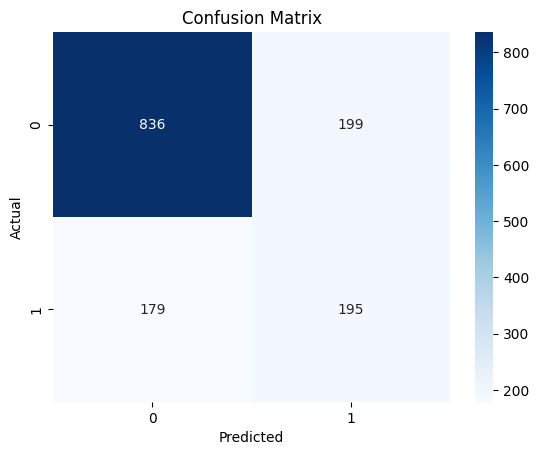

In [9]:
import seaborn as sns

#Matriz de confusion bonita usando seaborn
cm = confusion_matrix(y_test, test_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()
